In [1]:
import os
from collections import Counter
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter

from torchvision import transforms, datasets
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# Reproducibility & device
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_ROOT = "dataset"   # root that contains train/, val/, test/
os.makedirs("checkpoints", exist_ok=True)


Device: cuda


In [2]:
def get_transforms(mode="train", aug="light"):
    """mode in {'train', 'val'}; aug in {'light','strong','none'}."""
    gray_to_rgb = transforms.Grayscale(num_output_channels=3)
    train_mean = [0.5654, 0.5654, 0.5654]
    train_std  = [0.2212, 0.2212, 0.2212]
    if mode == "train":
        if aug == "strong":
            tf = transforms.Compose([
                transforms.Resize((224, 224)),
                gray_to_rgb,

                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(20),
                transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
                transforms.GaussianBlur(3),
                transforms.ToTensor(),
                transforms.Normalize(mean=train_mean, std=train_std),
            ])
        elif aug == "light":
            tf = transforms.Compose([
                transforms.Resize((224, 224)),
                gray_to_rgb,

                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(10),
                transforms.ToTensor(),
                transforms.Normalize(mean=train_mean, std=train_std),
            ])
        else:  # none
            tf = transforms.Compose([
                transforms.Resize((224, 224)),
                gray_to_rgb,

                transforms.ToTensor(),
                transforms.Normalize(mean=train_mean, std=train_std),
            ])
    else:  # val/test
        tf = transforms.Compose([
            transforms.Resize((224, 224)),
            gray_to_rgb,

            transforms.ToTensor(),
            transforms.Normalize(mean=train_mean, std=train_std),
        ])
    return tf

def build_efficientnet_b0(num_classes=2, pretrained=True):
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model = efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model.to(device)


In [3]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


def evaluate(model, loader, criterion=None):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            if criterion is not None:
                loss = criterion(outputs, labels)
                total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader) if criterion is not None else None
    acc = correct / total
    return avg_loss, acc


In [4]:
def kfold_train_efficientnet(
    k=5,
    epochs=4,
    batch_size=16,
    lr=1e-3,
    augment="light",
    log_dir_base="runs/efficientnet_kfold",
):
    """
    Returns:
        fold_results: list of dicts with per-fold stats
        best_fold: dict for the fold with highest best_val_acc
    """
    train_root = os.path.join(DATA_ROOT, "train")
    # val_root = os.path.join(DATA_ROOT, "val")  # use val set for k-fold

    # Dataset only for labels (no transforms)
    base_ds = datasets.ImageFolder(train_root)
    paths = [s[0] for s in base_ds.samples]
    labels = np.array([s[1] for s in base_ds.samples])
    class_names = base_ds.classes
    print("Train class distribution:", Counter(labels))

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(paths, labels), start=1):
        print(f"\n--- Fold {fold}/{k} ---")

        # Datasets with transforms
        train_tf = get_transforms("train", augment)
        val_tf = get_transforms("val")

        train_ds = datasets.ImageFolder(train_root, transform=train_tf)
        val_ds   = datasets.ImageFolder(train_root, transform=val_tf)

        train_subset = Subset(train_ds, train_idx)
        val_subset   = Subset(val_ds, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

        model = build_efficientnet_b0(num_classes=len(class_names))
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # TensorBoard writer for this fold
        timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
        log_dir = os.path.join(log_dir_base, f"fold_{fold}_{timestamp}")
        writer = SummaryWriter(log_dir=log_dir)

        best_val_acc = 0.0
        best_ckpt_path = f"checkpoints/efficientnet_fold{fold}_best.pth"

        for epoch in range(epochs):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
            val_loss, val_acc = evaluate(model, val_loader, criterion)

            print(f"Fold {fold}, Epoch {epoch+1}/{epochs} | "
                  f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

            # TensorBoard logging
            writer.add_scalar("Loss/train", train_loss, epoch)
            writer.add_scalar("Loss/val", val_loss, epoch)
            writer.add_scalar("Accuracy/train", train_acc, epoch)
            writer.add_scalar("Accuracy/val", val_acc, epoch)

            # Save best checkpoint per fold
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), best_ckpt_path)

        writer.add_hparams(
            {
                "lr": lr,
                "batch_size": batch_size,
                "augment": augment,
                "epochs": epochs,
            },
            {"hparam/best_val_acc": best_val_acc},
        )
        writer.close()

        fold_results.append({
            "fold": fold,
            "best_val_acc": best_val_acc,
            "ckpt_path": best_ckpt_path,
        })

    # choose best fold
    best_fold = max(fold_results, key=lambda d: d["best_val_acc"])
    print("\nK-Fold results:")
    for r in fold_results:
        print(r)
    mean_acc = np.mean([r["best_val_acc"] for r in fold_results])
    std_acc = np.std([r["best_val_acc"] for r in fold_results])
    print(f"\nK-Fold mean best val accuracy: {mean_acc:.4f} +/- {std_acc:.4f}")
    print("Best fold:", best_fold)

    return fold_results, best_fold, class_names


In [5]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader


train_mean = [0.5654, 0.5654, 0.5654]
train_std  = [0.2212, 0.2212, 0.2212]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    transforms.Resize((224, 224)),    # required!
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])



val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])

raw_train_ds = datasets.ImageFolder("dataset/train", transform=train_tf)
raw_val_ds   = datasets.ImageFolder("dataset/val", transform=val_tf)

raw_train_loader = DataLoader(raw_train_ds, batch_size=64, shuffle=False)
raw_val_loader   = DataLoader(raw_val_ds, batch_size=64, shuffle=False)
fold_results, best_fold, class_names = kfold_train_efficientnet(
    k=5, epochs=5, batch_size=64, lr=1e-3, augment="strong"
)


Train class distribution: Counter({1: 8835, 0: 2305})

--- Fold 1/5 ---


Fold 1, Epoch 1/5 | Train Acc: 0.9586, Val Acc: 0.9735


Fold 1, Epoch 2/5 | Train Acc: 0.9741, Val Acc: 0.9829


Fold 1, Epoch 3/5 | Train Acc: 0.9808, Val Acc: 0.9874


Fold 1, Epoch 4/5 | Train Acc: 0.9845, Val Acc: 0.9753


...

Fold 5, Epoch 1/5 | Train Acc: 0.9607, Val Acc: 0.9708


Fold 5, Epoch 2/5 | Train Acc: 0.9785, Val Acc: 0.9785


Fold 5, Epoch 3/5 | Train Acc: 0.9813, Val Acc: 0.9749


Fold 5, Epoch 4/5 | Train Acc: 0.9844, Val Acc: 0.9870


Fold 5, Epoch 5/5 | Train Acc: 0.9843, Val Acc: 0.9888

K-Fold results:
{'fold': 1, 'best_val_acc': 0.9874326750448833, 'ckpt_path': 'checkpoints/efficientnet_fold1_best.pth'}
{'fold': 2, 'best_val_acc': 0.9910233393177738, 'ckpt_path': 'checkpoints/efficientnet_fold2_best.pth'}
{'fold': 3, 'best_val_acc': 0.9865350089766607, 'ckpt_path': 'checkpoints/efficientnet_fold3_best.pth'}
{'fold': 4, 'best_val_acc': 0.9896768402154399, 'ckpt_path': 'checkpoints/efficientnet_fold4_best.pth'}
{'fold': 5, 'best_val_acc': 0.9887791741472173, 'ckpt_path': 'checkpoints/efficientnet_fold5_best.pth'}

K-Fold mean best val accuracy: 0.9887 +/- 0.0016
Best fold: {'fold': 2, 'best_val_acc': 0.9910233393177738, 'ckpt_path': 'checkpoints/efficientnet_fold2_best.pth'}


In [6]:
def get_test_loader(batch_size=32):
    test_root = os.path.join(DATA_ROOT, "test")
    test_tf = get_transforms("val")
    test_ds = datasets.ImageFolder(test_root, transform=test_tf)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return test_loader, test_ds.classes


def load_best_model(best_fold, num_classes):
    model = build_efficientnet_b0(num_classes=num_classes)
    ckpt_path = best_fold["ckpt_path"]
    print("Loading best checkpoint:", ckpt_path)
    state_dict = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state_dict)
    return model


def evaluate_on_test(best_fold, class_names):
    model = load_best_model(best_fold, num_classes=len(class_names))
    test_loader, test_class_names = get_test_loader()

    assert class_names == test_class_names, "Class order mismatch between train and test!"

    _, test_acc = evaluate(model, test_loader, criterion=None)
    print(f"\nBest fold model test accuracy: {test_acc:.4f}")

    # Export final model
    export_path = "runs/best_efficientnet_b0.pth"
    torch.save(model.state_dict(), export_path)
    print("Final model exported to:", export_path)

    return model, test_loader, test_acc


best_model, test_loader, test_acc = evaluate_on_test(best_fold, class_names)


Loading best checkpoint: checkpoints/efficientnet_fold2_best.pth

Best fold model test accuracy: 0.9059
Final model exported to: best_efficientnet_b0.pth


In [7]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.handles.append(self.target_layer.register_forward_hook(forward_hook))
        # use full backward hook for newer PyTorch
        self.handles.append(self.target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        for h in self.handles:
            h.remove()

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(1)

        loss = output[0, target_class]
        loss.backward()

        grads = self.gradients        # (B,C,H',W')
        acts = self.activations       # (B,C,H',W')
        weights = grads.mean(dim=(2, 3), keepdim=True)  # (B,C,1,1)

        cam = (weights * acts).sum(dim=1, keepdim=True)  # (B,1,H',W')
        cam = torch.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = torch.nn.functional.interpolate(
            cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False
        )

        return cam  # (1,1,H,W)


def get_efficientnet_target_layer(model):
    # For torchvision EfficientNet-B0, last conv block:
    return model.features[-1]


def show_gradcam_examples(model, loader, class_names, num_images=6):
    target_layer = get_efficientnet_target_layer(model)
    cam_gen = GradCAM(model, target_layer)

    shown = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)

        for i in range(imgs.size(0)):
            if shown >= num_images:
                cam_gen.remove_hooks()
                return

            img = imgs[i:i+1]
            label = labels[i].item()
            pred = preds[i].item()

            cam = cam_gen.generate(img)[0, 0].cpu().numpy()
            img_np = img[0].detach().cpu().permute(1,2,0).numpy()
            img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

            plt.figure(figsize=(8,3))
            plt.subplot(1,3,1)
            plt.imshow(img_np, cmap="gray")
            plt.title(f"Input\nGT: {class_names[label]}, Pred: {class_names[pred]}")
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.imshow(cam, cmap="jet")
            plt.title("Grad-CAM heatmap")
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.imshow(img_np, cmap="gray")
            plt.imshow(cam, cmap="jet", alpha=0.4)
            plt.title("Overlay")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            shown += 1

    cam_gen.remove_hooks()


In [8]:
    import gc
    gc.collect()

66

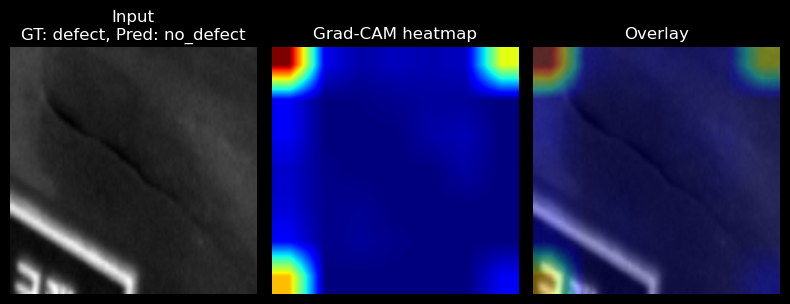

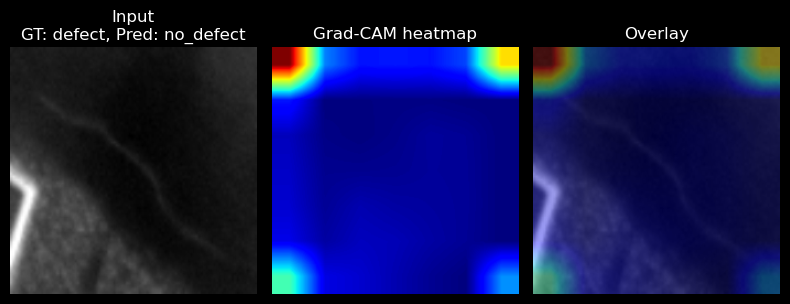

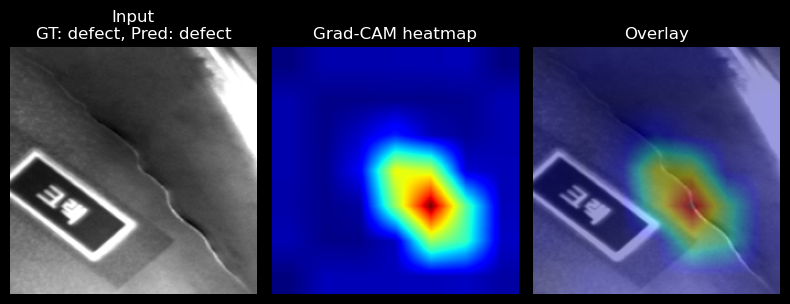

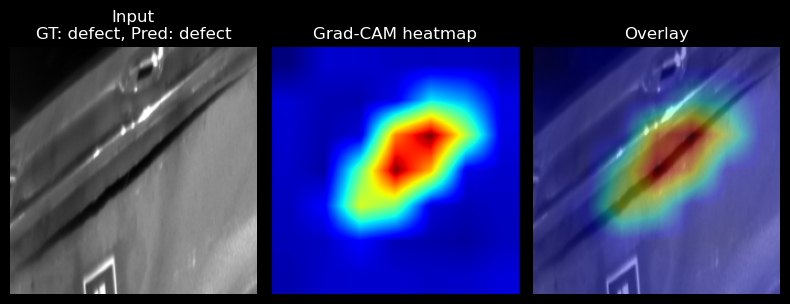

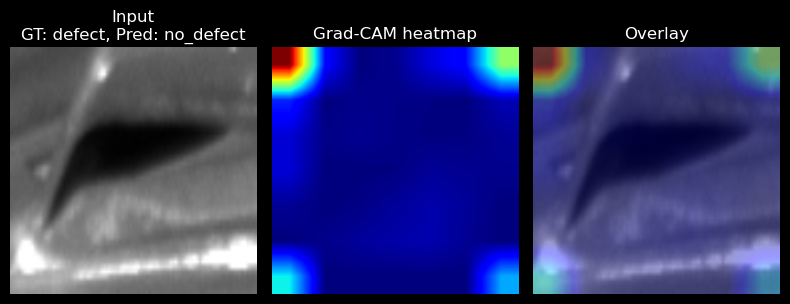

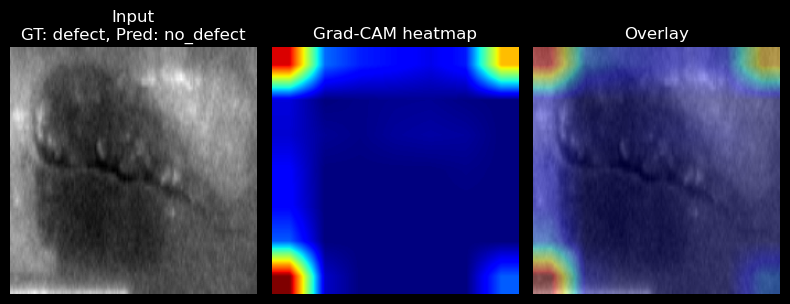

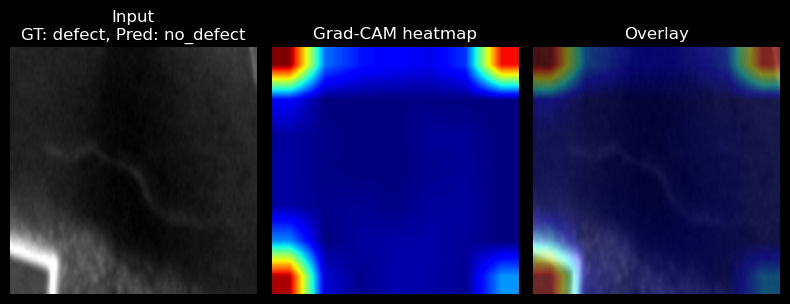

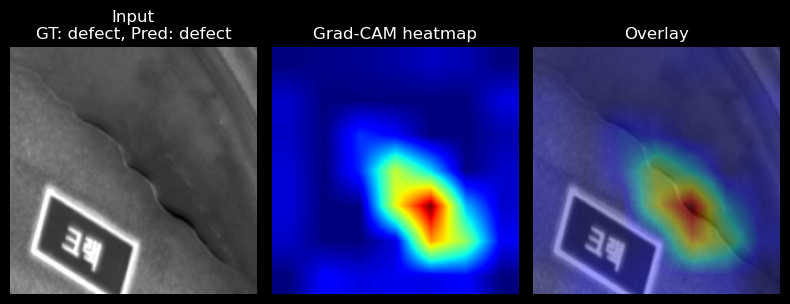

In [9]:
show_gradcam_examples(best_model, raw_val_loader, class_names, num_images=8)


In [10]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

raw_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # keep consistent
    transforms.ToTensor(),
])

raw_train_ds = datasets.ImageFolder("dataset/train", transform=raw_tf)
raw_val_ds   = datasets.ImageFolder("dataset/val", transform=raw_tf)

raw_train_loader = DataLoader(raw_train_ds, batch_size=64, shuffle=False)
raw_val_loader   = DataLoader(raw_val_ds, batch_size=64, shuffle=False)


In [11]:
def compute_mean_std(loader):
    mean = 0.0
    std = 0.0
    total_pixels = 0

    for imgs, _ in loader:
        # imgs shape: (B, C, H, W)
        b, c, h, w = imgs.shape
        pixels = b * h * w

        # sum mean over batch
        mean += imgs.sum(dim=[0,2,3])
        std  += (imgs ** 2).sum(dim=[0,2,3])

        total_pixels += pixels

    mean /= total_pixels
    std = torch.sqrt(std / total_pixels - mean ** 2)

    return mean, std


In [12]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch
import numpy as np

raw_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),    # required!
    transforms.ToTensor(),
])

train_raw_ds = datasets.ImageFolder("dataset/train", transform=raw_tf)
val_raw_ds   = datasets.ImageFolder("dataset/val",   transform=raw_tf)
test_raw_ds  = datasets.ImageFolder("dataset/test",  transform=raw_tf)

train_raw_loader = DataLoader(train_raw_ds, batch_size=64, shuffle=False)
val_raw_loader   = DataLoader(val_raw_ds,   batch_size=64, shuffle=False)
test_raw_loader  = DataLoader(test_raw_ds,  batch_size=64, shuffle=False)

def compute_mean_std(loader):
    mean = 0.0
    sq_mean = 0.0
    total_pixels = 0

    for imgs, _ in loader:
        imgs = imgs.to(torch.float32)
        b, c, h, w = imgs.shape
        pixels = b * h * w

        mean += imgs.sum(dim=[0,2,3])
        sq_mean += (imgs ** 2).sum(dim=[0,2,3])
        total_pixels += pixels

    mean /= total_pixels
    std = torch.sqrt(sq_mean / total_pixels - mean ** 2)
    return mean, std

train_mean, train_std = compute_mean_std(train_raw_loader)
val_mean, val_std     = compute_mean_std(val_raw_loader)
test_mean, test_std   = compute_mean_std(test_raw_loader)

print("TRAIN mean:", train_mean)
print("TRAIN std :", train_std)
print("VAL mean  :", val_mean)
print("VAL std   :", val_std)
print("TEST mean :", test_mean)
print("TEST std  :", test_std)



TRAIN mean: tensor([0.6083, 0.6083, 0.6083])
TRAIN std : tensor([0.2090, 0.2090, 0.2090])
VAL mean  : tensor([0.4117, 0.4117, 0.4117])
VAL std   : tensor([0.2447, 0.2447, 0.2447])
TEST mean : tensor([0.5662, 0.5662, 0.5662])
TEST std  : tensor([0.2198, 0.2198, 0.2198])


In [13]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch
import numpy as np

train_mean = [0.5654, 0.5654, 0.5654]
train_std  = [0.2212, 0.2212, 0.2212]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    transforms.Resize((224, 224)),    # required!
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])



val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])


train_raw_ds = datasets.ImageFolder("dataset/train", transform=train_tf)
val_raw_ds   = datasets.ImageFolder("dataset/val",   transform=val_tf)
test_raw_ds  = datasets.ImageFolder("dataset/test",  transform=train_tf)

train_raw_loader = DataLoader(train_raw_ds, batch_size=64, shuffle=False)
val_raw_loader   = DataLoader(val_raw_ds,   batch_size=64, shuffle=False)
test_raw_loader  = DataLoader(test_raw_ds,  batch_size=64, shuffle=False)

def compute_mean_std(loader):
    mean = 0.0
    sq_mean = 0.0
    total_pixels = 0

    for imgs, _ in loader:
        imgs = imgs.to(torch.float32)
        b, c, h, w = imgs.shape
        pixels = b * h * w

        mean += imgs.sum(dim=[0,2,3])
        sq_mean += (imgs ** 2).sum(dim=[0,2,3])
        total_pixels += pixels

    mean /= total_pixels
    std = torch.sqrt(sq_mean / total_pixels - mean ** 2)
    return mean, std

train_mean, train_std = compute_mean_std(train_raw_loader)
val_mean, val_std     = compute_mean_std(val_raw_loader)
test_mean, test_std   = compute_mean_std(test_raw_loader)

print("TRAIN mean:", train_mean)
print("TRAIN std :", train_std)
print("VAL mean  :", val_mean)
print("VAL std   :", val_std)
print("TEST mean :", test_mean)
print("TEST std  :", test_std)



TRAIN mean: tensor([0.1717, 0.1717, 0.1717])
TRAIN std : tensor([0.9501, 0.9501, 0.9501])
VAL mean  : tensor([-0.6947, -0.6947, -0.6947])
VAL std   : tensor([1.1061, 1.1061, 1.1061])
TEST mean : tensor([-0.0138, -0.0138, -0.0138])
TEST std  : tensor([0.9975, 0.9975, 0.9975])


In [14]:
from sklearn.model_selection import train_test_split
import shutil
import os
from collections import Counter
from torchvision import datasets

def build_new_val_split(
    train_dir="dataset/train",
    new_val_dir="dataset/new_val",
    test_size=0.15
):
    # 1. Load training dataset metadata
    ds = datasets.ImageFolder(train_dir)

    paths = [p for p, _ in ds.samples]
    labels = [c for _, c in ds.samples]

    # 2. Stratified random split
    X_train, X_val, y_train, y_val = train_test_split(
        paths, labels, test_size=test_size, stratify=labels, random_state=42
    )

    # 3. Create NEW validation folder
    os.makedirs(os.path.join(new_val_dir, "defect"), exist_ok=True)
    os.makedirs(os.path.join(new_val_dir, "no_defect"), exist_ok=True)

    # 4. Copy files into the new validation folder
    for p, y in zip(X_val, y_val):
        cls = ds.classes[y]  # "defect" or "no_defect"
        dest = os.path.join(new_val_dir, cls)
        shutil.copy(p, dest)

    print("New VAL distribution:", Counter(y_val))
    print(f"New validation set saved to: {new_val_dir}")


In [15]:
build_new_val_split(
    train_dir="dataset/train",
    new_val_dir="dataset/new_val",
    test_size=0.15
)

New VAL distribution: Counter({1: 1325, 0: 346})
New validation set saved to: dataset/new_val
